## 32.9) Exercício de PyCaret para Regressão

In [1]:
import pycaret
print(pycaret.__version__)

3.3.2


### ambiente do anaconda

In [2]:
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/pycaret-env/bin/python


biblioteca com as funções de regressão

In [3]:
import numpy as np

from pycaret.regression import (
    compare_models,
    create_model,
    evaluate_model,
    finalize_model,
    load_model,
    plot_model,
    predict_model,
    save_model,
    setup,
    tune_model
)

from pycaret.datasets import get_data

# PyCaret para Regressão

Neste exercício, você vai escolher outra base de dados do Pycaret para repetir a pipeline de treinamento realizada em aula.

Base de dados disponíveis

## Base de dados

Recupere todas as bases de dados disponibilizadas pelo Pycaret.

In [4]:
all_bases = get_data('index')

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


Desta vez, vamos utilizar o dataset `concrete`.

Recupere este dataset.

In [5]:

#      Dataset	        Data Types	Default Task	Target Variable 1	Target Variable 2	# Instances	# Attributes	Missing Values

# 47	concrete	Multivariate	Regression	  strength	                NaN	               1030	            9          	N

In [6]:
dataset = get_data('concrete')

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [7]:
list(dataset.columns[0:-1]) # atributos previsores, neste caso é numérico

['Cement (component 1)(kg in a m^3 mixture)',
 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
 'Fly Ash (component 3)(kg in a m^3 mixture)',
 'Water  (component 4)(kg in a m^3 mixture)',
 'Superplasticizer (component 5)(kg in a m^3 mixture)',
 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
 'Fine Aggregate (component 7)(kg in a m^3 mixture)',
 'Age (day)']

In [8]:
# algo para a previsão

list(dataset.columns[-1:]) 

['strength']

Verifique quantas instâncias e quantos atributos este dataset possui.

In [9]:
dataset.shape

(1030, 9)

Gere uma base de treinamento correspondente a 90% dos dados totais.

In [10]:
base_train = dataset.sample(frac=0.9, random_state=1)
base_train.shape

(927, 9)

Gere a base de testes, correspondente aos dados totais que não estão presentes na base de treinamento.

In [11]:
base_test = dataset.drop(base_train.index)
base_test.shape

(103, 9)

## Configuração do ambiente PyCaret

Gere um experimento, utilizando a base de treinamento, usando como variável alvo o atributo `strength`.

In [12]:
experiment = setup(data=base_train, target='strength', session_id=1)

,Description,Value
0,Session id,1
1,Target,strength
2,Target type,Regression
3,Original data shape,"(927, 9)"
4,Transformed data shape,"(927, 9)"
5,Transformed train set shape,"(648, 9)"
6,Transformed test set shape,"(279, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


In [13]:

# experiment = setup(data=base_train (dados de treino),
# target='strength' (coluna para a previsão), 
# session_id=1 (sempre gerar o mesmo valor se rodar depois
# )

## Treinamento de vários modelos com validação cruzada


Execute uma comparação de modelos, organizando os resultandos pela coluna `RMSE` (*root mean squared error*). Solicite 10 folds.

In [47]:
models = compare_models(sort='RMSE', fold=10)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,3.3928,24.3838,4.8085,0.9148,0.1543,0.1179,65.8880
et,Extra Trees Regressor,3.2914,24.3210,4.8264,0.9150,0.1535,0.1148,0.0280
gbr,Gradient Boosting Regressor,3.9095,29.5279,5.3223,0.8970,0.1710,0.1368,0.0170
rf,Random Forest Regressor,3.8778,29.9646,5.3708,0.8953,0.1745,0.1381,0.0410
dt,Decision Tree Regressor,4.4548,42.9026,6.4480,0.8470,0.2143,0.1571,0.0050
ada,AdaBoost Regressor,6.3165,60.4258,7.7366,0.7852,0.2890,0.2709,0.0140
knn,K Neighbors Regressor,7.2971,94.3552,9.6359,0.6661,0.3248,0.2907,0.0080
br,Bayesian Ridge,8.6275,117.7632,10.7750,0.5806,0.3501,0.3382,0.0070
ridge,Ridge Regression,8.6421,117.8391,10.7757,0.5805,0.3485,0.3369,0.0050
lr,Linear Regression,8.6421,117.8392,10.7757,0.5805,0.3485,0.3369,0.1810


Quanto menor o resultado melhor, RMSE

In [14]:
# --- RESUMO DAS MÉTRICAS DE REGRESSÃO ---

# MSE (Mean Squared Error): Média dos erros ao quadrado. 
# Foco: Penaliza fortemente erros grandes (outliers).
# MSE   -> Soma((Real - Previsto)^2) / n



# RMSE (Root Mean Squared Error): Raiz do MSE. 
# Foco: Erro médio na mesma unidade do preço (mais sensível que o MAE).
# RMSE  -> Raiz_Quadrada(MSE)


# R2 (R-Squared): Coeficiente de determinação. 
# Foco: Percentual da variação dos dados explicada pelo modelo (Ideal próximo a 1.0).
# R2    -> 1 - (Soma_Erros_Quadrados / Soma_Variacao_Total)


# RMSLE (Root Mean Squared Logarithmic Error): Erro logarítmico. 
# Foco: Útil quando o preço tem grandes variações; penaliza erro de proporção.
# RMSLE -> Raiz_Quadrada( Média( (log(Previsto + 1) - log(Real + 1))^2 ) )


# MAPE (Mean Absolute Percentage Error): Erro percentual médio. 
# Foco: Interpretabilidade fácil (ex: "o modelo erra em média 5% do valor").
# MAPE  -> Média( |(Real - Previsto) / Real| ) * 100

## Tuning dos modelos

In [15]:
 #       Model	                 MAE	MSE	      RMSE	R2	     RMSLE	MAPE	TT (Sec)
# et	Extra Trees Regressor	3.2914	24.3210	4.8264	0.9150	0.1535	0.1148	0.0720
# gbr	Gradient Boosting Regressor	3.9095	29.5279	5.3223	0.8970	0.1710	0.1368	0.0400
# rf	Random Forest Regressor	3.8778	29.9646	5.3708	0.8953	0.1745	0.1381	0.0980

In [16]:

 #       Model	                 MAE	MSE	      RMSE	R2	     RMSLE	MAPE	TT (Sec)
# lightgbm	Light Gradient Boosting Machine	3.3928	24.3838	4.8085	0.9148	0.1543	0.1179	65.8880
# et	Extra Trees Regressor	3.2914	24.3210	4.8264	0.9150	0.1535	0.1148	0.0280

Agora você vai testar o tuning do modelo com melhores resultados: Extra Trees Regressor.

Crie um modelo para Extra Trees Regressor

In [17]:
model_extra_trees_regressor = create_model('et')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.5647,37.5732,6.1297,0.8575,0.1951,0.1424
1,3.4029,26.6510,5.1625,0.9149,0.1527,0.1097
2,2.8674,15.7102,3.9636,0.9517,0.1254,0.0930
3,2.7049,14.3715,3.7910,0.9343,0.1206,0.0932
4,3.5860,24.3637,4.9360,0.9064,0.1685,0.1312
5,2.6794,13.7281,3.7051,0.9508,0.1534,0.1153
6,3.3128,23.8389,4.8825,0.9109,0.1865,0.1266
7,2.8411,18.7840,4.3340,0.9366,0.1258,0.0857
8,4.6924,49.4717,7.0336,0.8623,0.1915,0.1533


In [18]:
print(model_extra_trees_regressor)

ExtraTreesRegressor(n_jobs=-1, random_state=1)


### Execute o tuning do modelo.

para achar os melhores parâmetros

In [19]:
model_extra_trees_regressor_tuning = tune_model(model_extra_trees_regressor)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,7.5796,81.8643,9.0479,0.6896,0.3277,0.3256
1,7.2879,85.3936,9.2409,0.7274,0.3133,0.2991
2,6.0546,56.2015,7.4968,0.8271,0.3037,0.2732
3,5.7214,53.0847,7.2859,0.7572,0.3119,0.2865
4,5.6785,54.8413,7.4055,0.7894,0.2731,0.2391
5,6.7398,62.4756,7.9042,0.7761,0.3237,0.3177
6,7.0039,72.8671,8.5362,0.7277,0.2992,0.2824
7,6.6321,67.7132,8.2288,0.7716,0.2417,0.2232
8,8.2917,120.1189,10.9599,0.6657,0.3570,0.3374


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


o tuning o valor do RMSE subiu

In [20]:
print(model_extra_trees_regressor_tuning)

ExtraTreesRegressor(n_jobs=-1, random_state=1)


In [21]:
model_extra_trees_regressor_tuning.get_params()

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 1,
 'verbose': 0,
 'warm_start': False}

In [22]:
# --- Extra Trees Regressor (Parâmetros) ---

# n_estimators=100: Número de árvores na floresta. Mais árvores aumentam a 
# precisão, mas tornam o modelo mais lento.

# bootstrap=False: No Extra Trees, por padrão, usa-se o dataset inteiro em 
# cada árvore, ao invés de amostras aleatórias (Bootstrap). Isso reduz o viés.

# criterion='squared_error': Métrica para medir a qualidade dos cortes. 
# Busca minimizar a variância dos preços dentro de cada folha.

# max_depth=None: As árvores crescem até que as folhas fiquem "puras". 
# Se None, não há limite de profundidade (cuidado com overfitting).

# max_features=1.0: Em cada divisão, o modelo considera 100% das colunas. 
# Reduzir este valor (ex: 0.5) aumenta a velocidade e a diversidade das árvores.

# min_samples_split=2: O número mínimo de amostras necessárias para 
# dividir um nó interno.

# min_samples_leaf=1: O número mínimo de amostras que deve haver em uma folha. 
# Aumentar para 3 ou 5 ajuda a evitar que o modelo decore ruídos.

# n_jobs=-1: Usa todos os núcleos do seu processador para treinar as 
# árvores em paralelo, acelerando muito o processo.

# random_state=1: Semente para que os resultados sejam sempre iguais ao rodar o código.

# ccp_alpha=0.0: Parâmetro de poda. Valores maiores simplificam a árvore 
# cortando galhos pouco importantes.

# warm_start=False: Se True, permite reutilizar a floresta anterior para 
# adicionar mais árvores (treinamento incremental).

## Gráficos

Exiba um gráfico dos resíduos do modelo ajustado por tuning de parâmetros.

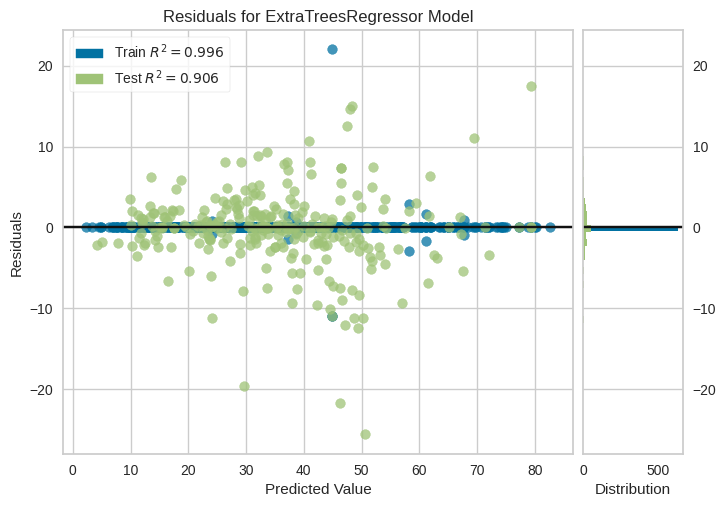

In [23]:
plot_model(model_extra_trees_regressor_tuning)

quanto mais distante os pontos da linha 0, maior é o erro.

Exiba um gráfico do erro do modelo ajustado por tuning de parâmetros.

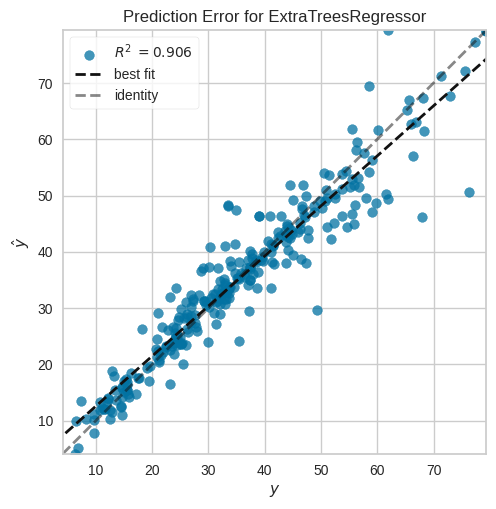

In [24]:
plot_model(model_extra_trees_regressor_tuning, plot="error") # erro, considerando a base de teste

### Exiba um gráfico da importância dos atributos (*feature importance*) do modelo ajustado por tuning de parâmetros.

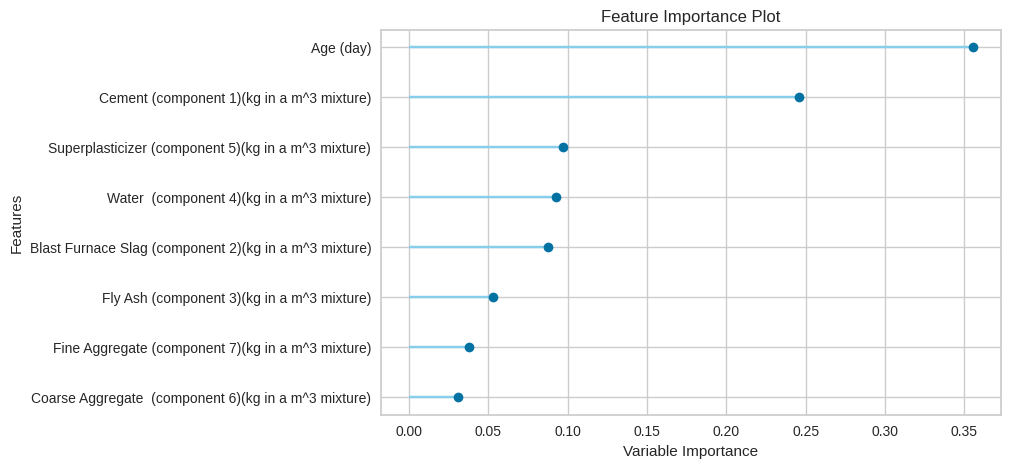

In [25]:
plot_model(model_extra_trees_regressor_tuning, 'feature')

Age e Cement são as colunas mais importantes da base

Exiba a avaliação do modelo.

In [26]:
evaluate_model(model_extra_trees_regressor_tuning)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

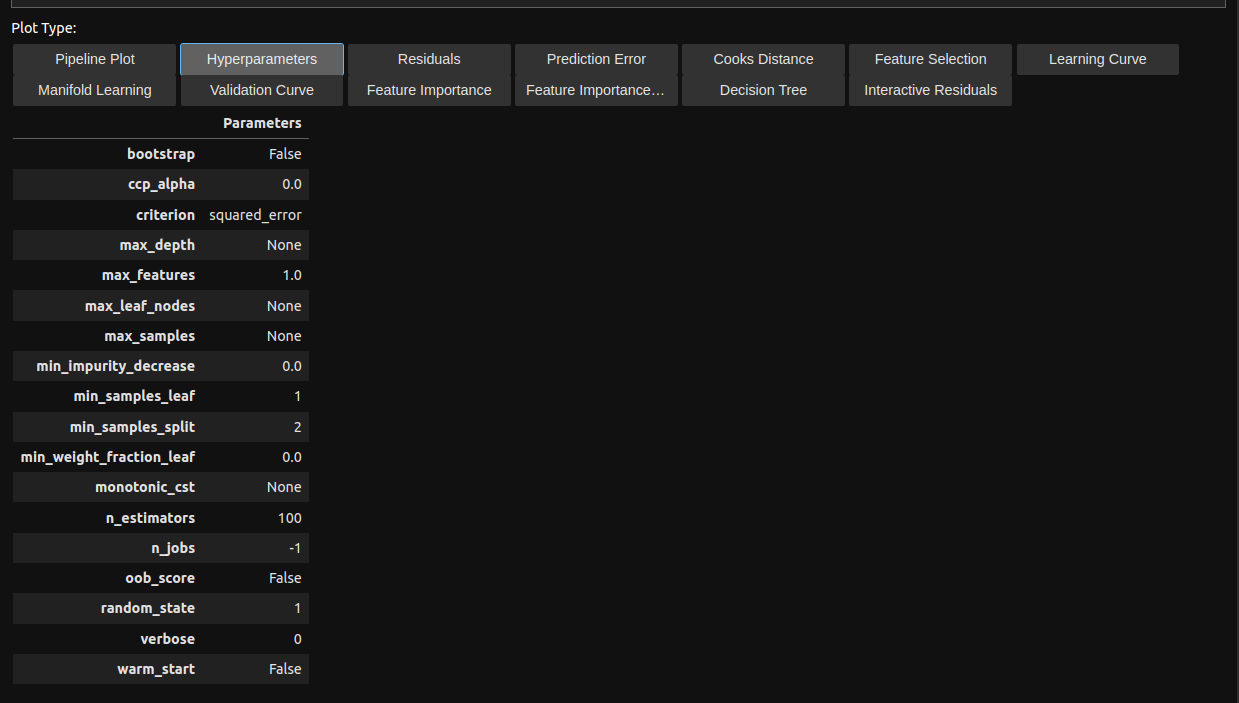

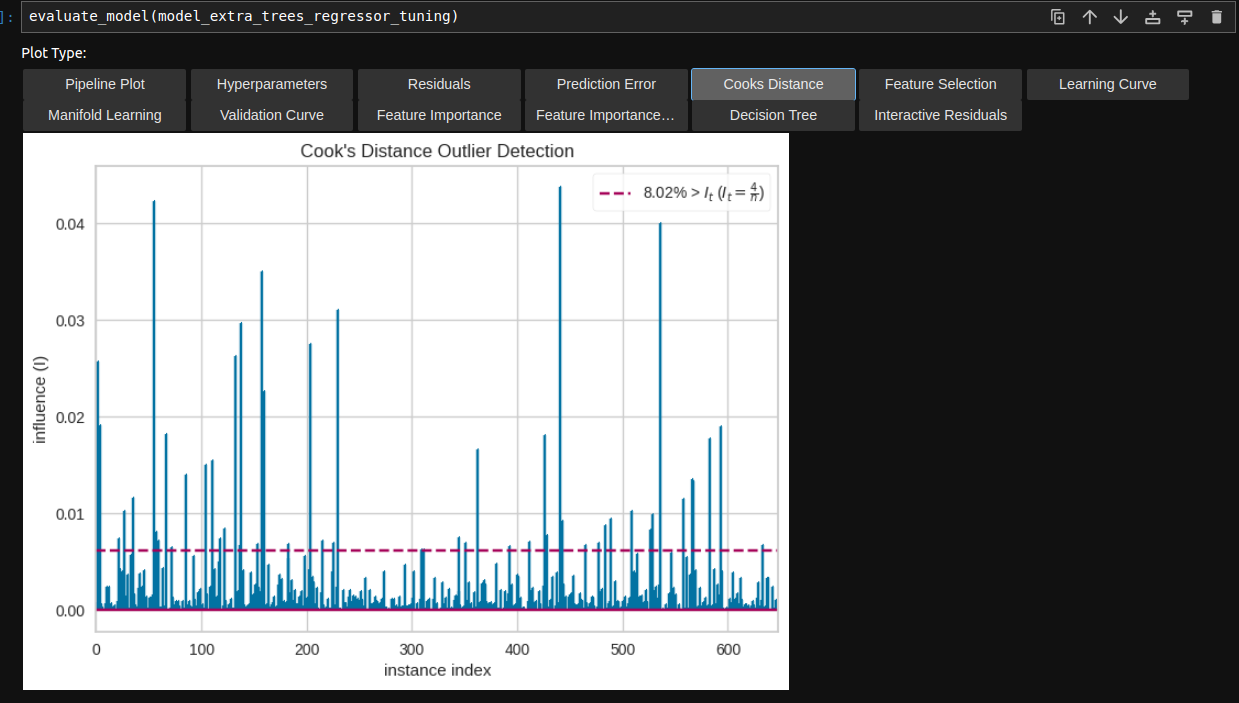

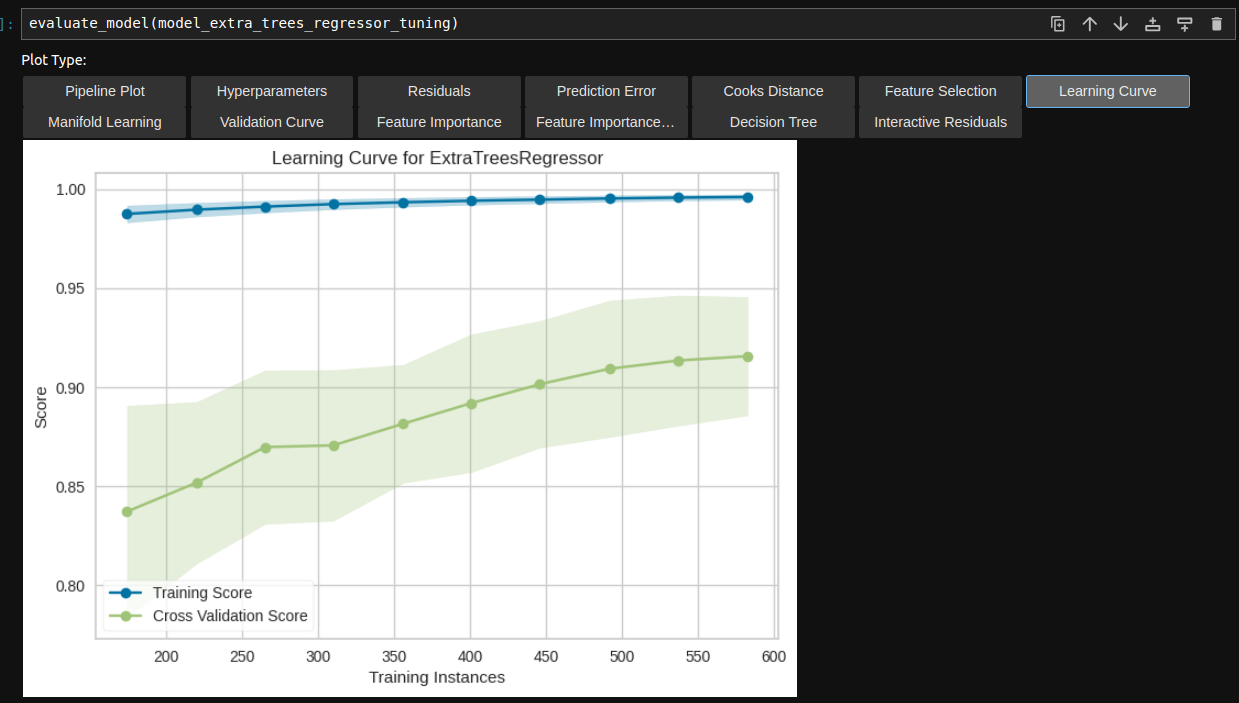

## Previsões com o modelo

Execute as previsões do modelo.

In [27]:
predict_model(model_extra_trees_regressor_tuning);

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,3.0713,23.3738,4.8346,0.9064,0.1325,0.0961


In [28]:
extra_trees_regressor_final = finalize_model(model_extra_trees_regressor_tuning)
print(extra_trees_regressor_final)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['Cement (component 1)(kg in a m^3 '
                                             'mixture)',
                                             'Blast Furnace Slag (component '
                                             '2)(kg in a m^3 mixture)',
                                             'Fly Ash (component 3)(kg in a '
                                             'm^3 mixture)',
                                             'Water  (component 4)(kg in a m^3 '
                                             'mixture)',
                                             'Superplasticizer (component '
                                             '5)(kg in a m^3 mixture)',
                                             'Coarse Aggregate  (component '
                                             '6)(kg in a m^3 mixture)',
                                             'Fine Aggregate 

In [29]:
extra_trees_regressor_final.get_params

<bound method Pipeline.get_params of Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['Cement (component 1)(kg in a m^3 '
                                             'mixture)',
                                             'Blast Furnace Slag (component '
                                             '2)(kg in a m^3 mixture)',
                                             'Fly Ash (component 3)(kg in a '
                                             'm^3 mixture)',
                                             'Water  (component 4)(kg in a m^3 '
                                             'mixture)',
                                             'Superplasticizer (component '
                                             '5)(kg in a m^3 mixture)',
                                             'Coarse Aggregate  (component '
                                             '6)(kg in a m^3 mixture)',
                        

In [30]:
# ExtraTreesRegressor(n_jobs=-1, random_state=1))

### Salve este modelo.

In [31]:
save_model(extra_trees_regressor_final, 'ExtraTreesRegressor_exercicio_regressao')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Cement (component 1)(kg in a m^3 '
                                              'mixture)',
                                              'Blast Furnace Slag (component '
                                              '2)(kg in a m^3 mixture)',
                                              'Fly Ash (component 3)(kg in a '
                                              'm^3 mixture)',
                                              'Water  (component 4)(kg in a m^3 '
                                              'mixture)',
                                              'Superplasticizer (component '
                                              '5)(kg in a m^3 mixture)',
                                              'Coarse Aggregate  (component '
                                              '6)(kg in a m^3 mixture)',
                                              '

In [32]:
# salvo como  'ExtraTreesRegressor_exercicio_regressao.pkl'

Recarregue o modelo salvo.

In [33]:
# lendo o arquivo salvo ExtraTreesRegressor_exercicio_regressao.pkl
extra_trees_regressor_loaded = load_model('ExtraTreesRegressor_exercicio_regressao')

Transformation Pipeline and Model Successfully Loaded


In [34]:
extra_trees_regressor_loaded

Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['Cement (component 1)(kg in a m^3 '
                                             'mixture)',
                                             'Blast Furnace Slag (component '
                                             '2)(kg in a m^3 mixture)',
                                             'Fly Ash (component 3)(kg in a '
                                             'm^3 mixture)',
                                             'Water  (component 4)(kg in a m^3 '
                                             'mixture)',
                                             'Superplasticizer (component '
                                             '5)(kg in a m^3 mixture)',
                                             'Coarse Aggregate  (component '
                                             '6)(kg in a m^3 mixture)',
                                             'Fine Aggregate (component 7)(kg '
                                             'in a m^3 mixture)',
                                             'Age (day)'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('clean_column_names',
                 TransformerWrapper(transformer=CleanColumnNames())),
                ('actual_estimator',
                 ExtraTreesRegressor(n_jobs=-1, random_state=1))])

In [35]:
extra_trees_regressor_loaded.get_params

<bound method Pipeline.get_params of Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['Cement (component 1)(kg in a m^3 '
                                             'mixture)',
                                             'Blast Furnace Slag (component '
                                             '2)(kg in a m^3 mixture)',
                                             'Fly Ash (component 3)(kg in a '
                                             'm^3 mixture)',
                                             'Water  (component 4)(kg in a m^3 '
                                             'mixture)',
                                             'Superplasticizer (component '
                                             '5)(kg in a m^3 mixture)',
                                             'Coarse Aggregate  (component '
                                             '6)(kg in a m^3 mixture)',
             

<div class="alert alert-block alert-info">
    <b>Info:</b> Utilize este bloco para destacar informações sobre o Extra Trees.
</div>

<div class="alert alert-block alert-success">
    <b>Sucesso:</b> O modelo foi recarregado com sucesso na base de testes.
</div>

In [36]:
# <div class="alert alert-block alert-success">
#     <b>Sucesso:</b> O modelo foi recarregado com sucesso na base de testes.
# </div>

<font color="red">Este texto ficará vermelho</font>
<font color="#28a745">Este texto ficará verde (Hexadecimal)</font>



  <h1>Meu Modelo de Machine Learning</h1>
 <b> <p>Faça previsões com o modelo  <font color="#28a745">recarregado na base de testes.</font> </b>




In [ ]:
 #  <h1>Meu Modelo de Machine Learning</h1>
 # <b> <p>Faça previsões com o modelo  <font color="#28a745">recarregado na 
#base de testes.</font> </b>


In [38]:
prevision = predict_model(extra_trees_regressor_loaded, data=base_test)
prevision

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,3.4377,31.7612,5.6357,0.8963,0.1541,0.1136


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),strength,prediction_label
7,380.000000,95.000000,0.000000,228.000000,0.0,932.000000,594.000000,28,36.450001,38.129301
15,380.000000,0.000000,0.000000,228.000000,0.0,932.000000,670.000000,90,52.910000,49.504700
22,139.600006,209.399994,0.000000,192.000000,0.0,1047.000000,806.900024,3,8.060000,9.120000
25,380.000000,0.000000,0.000000,228.000000,0.0,932.000000,670.000000,270,53.299999,52.446501
26,380.000000,95.000000,0.000000,228.000000,0.0,932.000000,594.000000,270,41.150002,42.092699
...,...,...,...,...,...,...,...,...,...,...
964,143.699997,170.199997,132.600006,191.600006,8.5,814.099976,805.299988,28,29.870001,29.898201
971,312.700012,144.699997,0.000000,127.300003,8.0,999.700012,822.200012,28,44.520000,44.626200
972,145.699997,172.600006,0.000000,181.899994,3.4,985.799988,816.799988,28,23.740000,24.297100
983,136.399994,161.600006,125.800003,171.600006,10.4,922.599976,764.400024,28,29.070000,31.140400


In [39]:
prevision.tail(50) # real (strength) e previsão prediction_label

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),strength,prediction_label
508,424.000000,22.000000,132.000000,178.000000,8.5,882.000000,750.000000,3,32.009998,30.649400
513,424.000000,22.000000,132.000000,168.000000,8.9,822.000000,750.000000,7,40.290001,38.904000
515,202.000000,11.000000,141.000000,206.000000,1.7,942.000000,801.000000,28,21.969999,24.420100
534,393.000000,0.000000,0.000000,192.000000,0.0,940.599976,785.599976,3,19.200001,18.051300
542,255.000000,0.000000,0.000000,192.000000,0.0,889.799988,945.000000,90,21.860001,27.003600
561,397.000000,0.000000,0.000000,185.699997,0.0,1040.599976,734.299988,28,33.080002,37.422799
562,382.500000,0.000000,0.000000,185.699997,0.0,1047.800049,739.299988,7,24.070000,23.882600
580,290.200012,193.500000,0.000000,185.699997,0.0,998.200012,704.299988,7,21.860001,23.122700
583,210.699997,316.100006,0.000000,185.699997,0.0,977.000000,689.299988,28,37.810001,37.627601
588,186.199997,124.099998,0.000000,185.699997,0.0,1083.400024,764.299988,7,8.000000,10.885000


## Tuning dos modelos agora para o Light Gradient Boosting Machine

Agora você vai testar o tuning do modelo com melhores resultados: Extreme Gradient Boosting.

Crie um modelo para Extreme Gradient Boosting.

In [13]:
lightgbm = create_model('lightgbm')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.8449,37.5808,6.1303,0.8575,0.1870,0.1460
1,3.9762,27.9055,5.2826,0.9109,0.1718,0.1347
2,3.2747,21.4663,4.6332,0.9340,0.1400,0.1055
3,3.0197,16.8347,4.1030,0.9230,0.1397,0.1093
4,3.0530,17.1699,4.1437,0.9341,0.1439,0.1105
5,2.3515,9.7617,3.1244,0.9650,0.1121,0.0926
6,3.9474,27.4053,5.2350,0.8976,0.2101,0.1503
7,2.6731,13.3615,3.6553,0.9549,0.1256,0.0858
8,4.4169,50.5832,7.1122,0.8592,0.1888,0.1431


Exiba os parâmetros deste modelo.

In [14]:
print(lightgbm)

LGBMRegressor(n_jobs=-1, random_state=1)


Execute o tuning do modelo.

In [15]:
#lightgbm_tuning = tune_model(lightgbm)

1. Limitar o número de iterações (n_iter)
O parâmetro mais importante para velocidade. Em vez do padrão, tente 5 ou até menos se estiver com pressa.
    
2. busca simplificada (choose_better)
Você pode forçar o PyCaret a usar uma grade de parâmetros (grid) mais otimizada ou usar o search_library.



In [16]:
# search_library='scikit-learn': Geralmente mais rápido que o padrão (Optuna) para bases menores.
#lightgbm_tuning = tune_model(lightgbm, n_iter = 5, search_library = 'scikit-learn')

In [17]:
#3. Early Stopping (Parada Antecipada)
#Isso evita que o LightGBM perca tempo tentando criar árvores quando o erro parou de cair (resolvendo o aviso de No further splits).
# Passando parâmetros de parada direto para o LightGBM dentro do tune_model
#lightgbm_tuning = tune_model(lightgbm, early_stopping_rounds = 10)


# O parâmetro correto é 'early_stopping' e 'n_iter' para velocidade
lightgbm_tuning = tune_model(
    lightgbm, 
    early_stopping = True,      # Ativa a parada antecipada
    n_iter = 1,                 # Diminui as tentativas (muito mais rápido) 5 ou 10
    choose_better = True        # Garante que se o tuning piorar, ele mantém o original
)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.5249,30.1853,5.4941,0.8855,0.2203,0.1447
1,3.5659,28.3474,5.3242,0.9095,0.1648,0.1148
2,3.1781,22.4968,4.7431,0.9308,0.1501,0.1102
3,2.5855,13.2993,3.6468,0.9392,0.1292,0.0946
4,3.3280,18.1227,4.2571,0.9304,0.1707,0.1345
5,2.7921,13.1480,3.6260,0.9529,0.1425,0.1058
6,3.3008,18.6104,4.3140,0.9304,0.1590,0.1242
7,2.4194,10.6670,3.2660,0.9640,0.1171,0.0814
8,3.9065,44.5875,6.6774,0.8759,0.1837,0.1340


Fitting 10 folds for each of 1 candidates, totalling 10 fits


In [26]:
# lightgbm = create_model(
#     'lightgbm',
#     n_estimators=100,   # ↓ menos árvores
#     max_depth=6,        # ↓ árvores rasas
#     learning_rate=0.1,
#     verbose=False
# )


In [27]:
print(lightgbm_tuning)

LGBMRegressor(bagging_fraction=0.8, bagging_freq=3, feature_fraction=0.5,
              learning_rate=0.3, min_child_samples=26, min_split_gain=0.8,
              n_estimators=230, n_jobs=-1, num_leaves=100, random_state=1,
              reg_alpha=0.005, reg_lambda=4)


In [29]:
# --- LightGBM Regressor (Parâmetros Tunados) ---

# bagging_fraction=0.8: O modelo usa apenas 80% dos dados para treinar cada árvore.
# Isso introduz aleatoriedade e ajuda a evitar o decoro de dados (overfitting).

# bagging_freq=3: Executa o 'bagging' (sorteio de dados) a cada 3 iterações. 
# Ajuda na estabilidade do treinamento.

# feature_fraction=0.5: Há 55 colunas, o modelo escolhe apenas 
# 50% delas (27 ou 28) ao acaso para cada árvore. Essencial para reduzir o ruído.

# learning_rate=0.3: Velocidade de aprendizado. Um valor de 0.3 é moderado-alto; 
# o modelo aprende rápido, mas requer cuidado para não passar do ponto ideal.

# min_child_samples=26: Cada "folha" da árvore deve ter pelo menos 26 amostras. 
# Evita que o modelo crie regras para grupos muito pequenos de dados.

# min_split_gain=0.8: A árvore só faz um novo corte se houver uma melhora 
# de pelo menos 0.8 no erro. Reduz a complexidade da árvore.

# n_estimators=230: O número total de árvores sequenciais que serão criadas.

# num_leaves=100: Máximo de folhas em uma única árvore. Como o valor é alto, 
# a árvore pode ser complexa, mas é limitada pelos outros parâmetros acima.

# reg_alpha=0.005 e reg_lambda=4: Regularização L1 e L2. Eles "punem" o modelo 
# por pesos muito grandes, forçando-o a ser mais simples e generalista.

# n_jobs=-1: Utiliza todos os processadores da máquina para ganhar velocidade.

In [50]:
# --- AJUSTES DE PERFORMANCE NO TUNE_MODEL ---

# early_stopping=True: Faz o modelo parar de treinar se o erro parar de cair 
# nas validações cruzadas, economizando tempo e processamento.

# n_iter=5: Por padrão o PyCaret tenta 10 combinações. 
# Reduzir para 5 corta o tempo de espera pela metade.

# choose_better=True: Filtro de segurança. Às vezes o tuning (aleatório) 
# encontra um resultado pior que o padrão. Isso garante que o PyCaret 
# retorne o melhor dos dois mundos.

## Gráficos

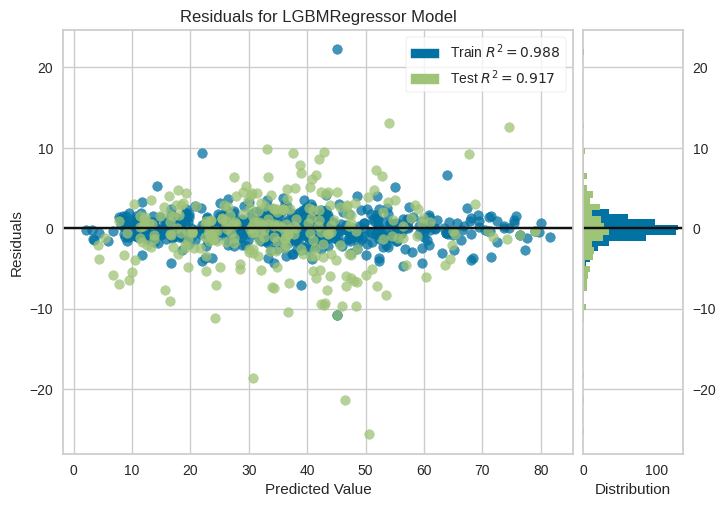

In [18]:
plot_model(lightgbm_tuning)

Exiba um gráfico do erro do modelo ajustado por tuning de parâmetros.

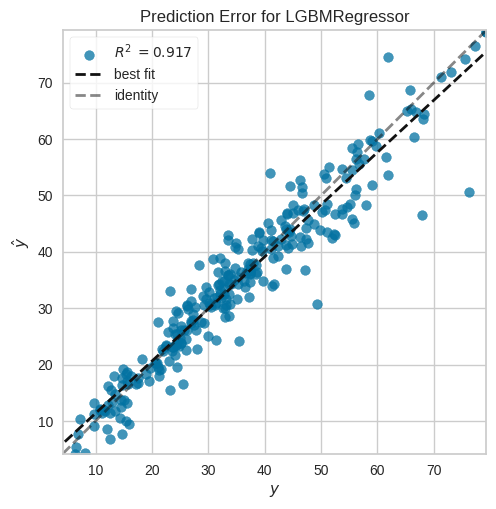

In [19]:
plot_model(lightgbm_tuning, plot="error")

Exiba um gráfico da importância dos atributos (*feature importance*) do modelo ajustado por tuning de parâmetros.

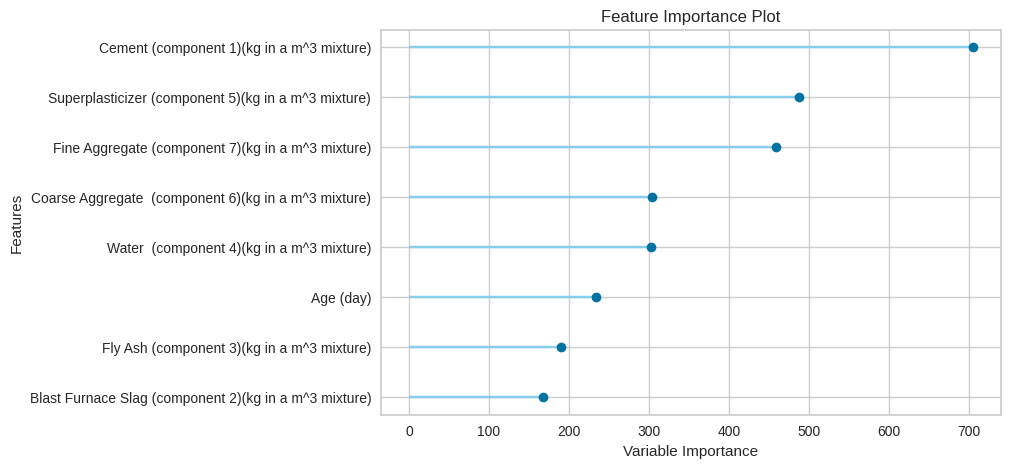

In [20]:
plot_model(lightgbm_tuning, 'feature')

## Previsões com o modelo

In [21]:
predict_model(lightgbm_tuning);

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,3.1435,20.7858,4.5591,0.9167,0.1423,0.1007


[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [22]:
lightgbm_final = finalize_model(lightgbm_tuning)
print(lightgbm_final)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['Cement (component 1)(kg in a m^3 '
                                             'mixture)',
                                             'Blast Furnace Slag (component '
                                             '2)(kg in a m^3 mixture)',
                                             'Fly Ash (component 3)(kg in a '
                                             'm^3 mixture)',
                                             'Water  (component 4)(kg in a m^3 '
                                             'mixture)',
                                             'Superplasticizer (component '
                                             '5)(kg in a m^3 mixture)',
                                             'Coarse Aggregate  (component '
                                             '6)(kg in a m...
                                    transformer=SimpleImputer(strategy=

Salve este modelo.

In [23]:
save_model(lightgbm_final, 'lightgbm_exercicio_regressao')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Cement (component 1)(kg in a m^3 '
                                              'mixture)',
                                              'Blast Furnace Slag (component '
                                              '2)(kg in a m^3 mixture)',
                                              'Fly Ash (component 3)(kg in a '
                                              'm^3 mixture)',
                                              'Water  (component 4)(kg in a m^3 '
                                              'mixture)',
                                              'Superplasticizer (component '
                                              '5)(kg in a m^3 mixture)',
                                              'Coarse Aggregate  (component '
                                              '6)(kg in a m...
                                     transformer=SimpleIm

Recarregue o modelo salvo.

In [24]:
lightgbm_loaded = load_model('lightgbm_exercicio_regressao')

Transformation Pipeline and Model Successfully Loaded


In [25]:
prevision2 = predict_model(lightgbm_loaded, data=base_test)
prevision2

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,2.9178,20.3728,4.5136,0.9335,0.1265,0.0976


[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),strength,prediction_label
7,380.000000,95.000000,0.000000,228.000000,0.0,932.000000,594.000000,28,36.450001,37.818211
15,380.000000,0.000000,0.000000,228.000000,0.0,932.000000,670.000000,90,52.910000,49.200937
22,139.600006,209.399994,0.000000,192.000000,0.0,1047.000000,806.900024,3,8.060000,10.118162
25,380.000000,0.000000,0.000000,228.000000,0.0,932.000000,670.000000,270,53.299999,52.517409
26,380.000000,95.000000,0.000000,228.000000,0.0,932.000000,594.000000,270,41.150002,42.526714
...,...,...,...,...,...,...,...,...,...,...
964,143.699997,170.199997,132.600006,191.600006,8.5,814.099976,805.299988,28,29.870001,31.224177
971,312.700012,144.699997,0.000000,127.300003,8.0,999.700012,822.200012,28,44.520000,46.950341
972,145.699997,172.600006,0.000000,181.899994,3.4,985.799988,816.799988,28,23.740000,24.841433
983,136.399994,161.600006,125.800003,171.600006,10.4,922.599976,764.400024,28,29.070000,36.073548
